In [1]:
"""
Teste Def homogeneus_model_xarray
"""
import numpy as np
import matplotlib.pyplot as plt
import bordado as bd

from _utils import homogeneous_model_xarray
from _acoustic_xarray import AcousticXarray
from _wavelets import RickerWavelet

#region = [xmin, xmax, zmin, zmax]
region = [0, 3000, 0, 2000]
shape = (300, 400)
props = {"velocity": 1500.00, "density": 1000.00}
#print(f'Região:{region}')
#print(f'Shape: {shape}')
#print(f'Propriedades: {props}')

model = homogeneous_model_xarray(region,shape,props)
model

<xarray.Dataset> Size: 966kB
Dimensions:   (z: 300, x: 400)
Coordinates:
  * z         (z) float64 2kB 0.0 6.689 13.38 ... 1.987e+03 1.993e+03 2e+03
  * x         (x) float64 3kB 0.0 7.519 15.04 ... 2.985e+03 2.992e+03 3e+03
Data variables:
    velocity  (z, x) float32 480kB 1.5e+03 1.5e+03 1.5e+03 ... 1.5e+03 1.5e+03
    density   (z, x) float32 480kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
Attributes:
    dx:       7.518796992481203
    dz:       6.688963210702341
    region:   [0, 3000, 0, 2000]

In [6]:
bd.grid_coordinates([0, 10, 0, 10], spacing=3, adjust="region")

(array([[0.5, 3.5, 6.5, 9.5],
        [0.5, 3.5, 6.5, 9.5],
        [0.5, 3.5, 6.5, 9.5],
        [0.5, 3.5, 6.5, 9.5]]),
 array([[0.5, 0.5, 0.5, 0.5],
        [3.5, 3.5, 3.5, 3.5],
        [6.5, 6.5, 6.5, 6.5],
        [9.5, 9.5, 9.5, 9.5]]))

Output()

c:\Users\paulo\miniforge3\envs\tremelique-env\Lib\site-packages\numba\core\typed_passes.py:336: 
NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see 
https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "_acoustic_xarray.py", line 374:
@numba.jit(nopython=True, parallel=True)
def timestep_esg(u_tp1, u_t, u_tm1, x1, x2, z1, z2, dt, dx, dz, vel, dens):
^

  warnings.warn(errors.NumbaPerformanceWarning(msg,

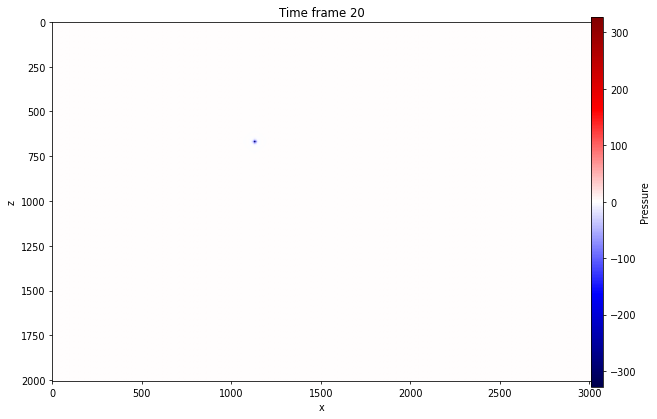

In [1]:
#print(f'dz = {model.attrs["dz"]} metros \ndx = {model.attrs["dx"]} metros')

sim = AcousticXarray(model=model, dt=0.001)
sim.add_point_source((100,150),RickerWavelet(1,60))

sim.run(100)
sim.snapshot(20, embed=True)